[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://github.com/porterjenkins/byu-cs474/blob/master/lab10_diffusion.ipynb)

# Denoising Diffusion Probabilistic Models (DDPM)

## Description

In this lab, we train an image generation model using diffusion. Diffusion is just one of several techniques to generate images, but it has recently surpassed the GAN as the state-of-the-art generation model.

The diffusion model is trained to remove noise from images, and once it is fully trained it can take random noise and fully "denoise" it into an image that looks reasonably like the training set.

## Objectives
- Implement forward process of diffusion
- Implement backward process of diffusion
- Generate images with the diffusion process
- Answer questions about diffusion

## Grading Criteria
- Scheduling (10%)
- Forward Diffusion (30%)
- Backward Diffusion (30%)
- Image Generation (20%)
- Answers to Questions (10%)

### Helpful Reading
- Denoising Diffusion Probabilistic Models: https://arxiv.org/abs/2006.11239
- Improved Denoising Diffusion Probabilistic Models: https://arxiv.org/abs/2102.09672



In [1]:
from abc import abstractmethod
import math
import matplotlib.pyplot as plt
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import DataLoader
import torchvision
from torchvision.transforms import Compose, Resize, Lambda, ToTensor

device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")

In [2]:
# Hyperparameters
MAX_TIMESTEPS = 2000
image_size = 32
lr = 3e-5

We have given you a simpler version of the UNet used in "Improved Denoising Diffusion Probabilistic Models." Feel free to familiarize yourself with the model. It is similar to the UNet we made in the cancer detection lab, but has layers that incorporate the timestep embedding. The model is already fully implemented.

In [3]:
def zero_module(module):
    for p in module.parameters():
        p.detach().zero_()
    return module


def timestep_embedding(timesteps, dim, max_period=10000):
    half = dim // 2
    freqs = torch.exp(
        -math.log(max_period) * torch.arange(start=0, end=half, dtype=torch.float32) / half
    ).to(device=timesteps.device)
    args = timesteps[:, None].float() * freqs[None]
    embedding = torch.cat([torch.cos(args), torch.sin(args)], dim=-1)
    if dim % 2:
        embedding = torch.cat([embedding, torch.zeros_like(embedding[:, :1])], dim=-1)
    return embedding


# Note: this is an abstract method, do not implement `forward`
class TimestepBlock(nn.Module):
    @abstractmethod
    def forward(self, x, emb):
        """
        Apply the module to `x` given `emb` timestep embeddings.
        """


class TimestepEmbedSequential(nn.Sequential, TimestepBlock):
    def forward(self, x, emb):
        for layer in self:
            if isinstance(layer, TimestepBlock):
                x = layer(x, emb)
            else:
                x = layer(x)
        return x


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.conv = nn.Conv2d(channels, channels, 3, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.channels
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = self.conv(x)
        return x


class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channels = channels
        self.op = nn.Conv2d(channels, channels, 3, stride=2, padding=1)

    def forward(self, x):
        assert x.shape[1] == self.channels
        return self.op(x)


class ResBlock(TimestepBlock):
    def __init__(
        self,
        channels,
        emb_channels,
        dropout,
        out_channels=None,
    ):
        super().__init__()
        self.channels = channels
        self.emb_channels = emb_channels
        self.dropout = dropout
        self.out_channels = out_channels or channels

        self.in_layers = nn.Sequential(
            nn.GroupNorm(32, channels),
            nn.SiLU(),
            nn.Conv2d(channels, self.out_channels, 3, padding=1)
        )
        self.emb_layers = nn.Sequential(
            nn.SiLU(),
            nn.Linear(emb_channels, self.out_channels)
        )
        self.out_layers = nn.Sequential(
            nn.GroupNorm(32, self.out_channels),
            nn.SiLU(),
            nn.Dropout(p=dropout),
            zero_module(nn.Conv2d(self.out_channels, self.out_channels, 3, padding=1)),
        )

        if self.out_channels == channels:
            self.skip_connection = nn.Identity()
        else:
            self.skip_connection = nn.Conv2d(channels, self.out_channels, kernel_size=1)

    def forward(self, x, emb):
        h = self.in_layers(x)
        emb_out = self.emb_layers(emb).type(h.dtype)
        while len(emb_out.shape) < len(h.shape):
            emb_out = emb_out[..., None]
        h = h + emb_out
        h = self.out_layers(h)
        return self.skip_connection(x) + h


class UNetModel(nn.Module):
    """
    The full UNet model with timestep embedding.

    :param in_channels: channels in the input Tensor.
    :param model_channels: base channel count for the model.
    :param out_channels: channels in the output Tensor.
    :param num_res_blocks: number of residual blocks per downsample.
    :param dropout: the dropout probability.
    :param channel_mult: channel multiplier for each level of the UNet.
    """

    def __init__(
        self,
        in_channels,
        hidden_channels,
        out_channels,
        num_res_blocks,
        dropout=0,
        channel_mult=(1, 2, 4, 8),
    ):
        super().__init__()
        self.in_channels = in_channels
        self.model_channels = hidden_channels
        self.out_channels = out_channels
        self.num_res_blocks = num_res_blocks
        self.dropout = dropout
        self.channel_mult = channel_mult

        time_embed_dim = hidden_channels * 4
        self.time_embed = nn.Sequential(
            nn.Linear(hidden_channels, time_embed_dim),
            nn.SiLU(),
            nn.Linear(time_embed_dim, time_embed_dim),
        )

        self.input_blocks = nn.ModuleList([
            TimestepEmbedSequential(nn.Conv2d(in_channels, hidden_channels, 3, padding=1))
        ])
        input_block_chans = [hidden_channels]
        ch = hidden_channels
        ds = 1
        for level, mult in enumerate(channel_mult):
            for _ in range(num_res_blocks):
                layers = [ResBlock(ch, time_embed_dim, dropout, out_channels=mult * hidden_channels)]
                ch = mult * hidden_channels
                self.input_blocks.append(TimestepEmbedSequential(*layers))
                input_block_chans.append(ch)
            if level != len(channel_mult) - 1:
                self.input_blocks.append(TimestepEmbedSequential(Downsample(ch)))
                input_block_chans.append(ch)
                ds *= 2

        self.middle_block = TimestepEmbedSequential(
            ResBlock(ch, time_embed_dim, dropout),
            ResBlock(ch, time_embed_dim, dropout),
        )

        self.output_blocks = nn.ModuleList([])
        for level, mult in list(enumerate(channel_mult))[::-1]:
            for i in range(num_res_blocks + 1):
                layers = [
                    ResBlock(
                        ch + input_block_chans.pop(),
                        time_embed_dim,
                        dropout,
                        out_channels=hidden_channels * mult,
                    )
                ]
                ch = hidden_channels * mult
                if level and i == num_res_blocks:
                    layers.append(Upsample(ch))
                    ds //= 2
                self.output_blocks.append(TimestepEmbedSequential(*layers))

        self.out = nn.Sequential(
            nn.GroupNorm(32, ch),
            nn.SiLU(),
            zero_module(nn.Conv2d(hidden_channels, out_channels, 3, padding=1))
        )

    def forward(self, x, timesteps):
        """
        Apply the model to an input batch.

        :param x: an [N x C x H x W] Tensor of inputs.
        :param timesteps: a 1-D batch of timesteps.
        :return: an [N x C x H x W] Tensor of outputs.
        """

        xs = []
        emb = self.time_embed(timestep_embedding(timesteps, self.model_channels))

        for module in self.input_blocks:
            x = module(x, emb)
            xs.append(x)
        x = self.middle_block(x, emb)
        for module in self.output_blocks:
            cat_in = torch.cat([x, xs.pop()], dim=1)
            x = module(cat_in, emb)
        return self.out(x)


# Part 1: Implement a linear and cosine scheduler

A scheduler is an important aspect to training a diffusion model. The scheduler returns a sequence of $\beta$ values, i.e. $[\beta_1, \cdots, \beta_T]$, that help determine how much noise is added to an image for training (forward process) and is removed from an image for inference (backward process). While the linear and cosine beta schedulers are valid ways of computing $\beta$s, the cosine scheduler is a better choice. Both schedulers should return 1-D tensors containing $[\beta_1, \cdots, \beta_T]$.

While we will only use t=1...T in training, we will need $\bar{\alpha}_0=1$ in the sampling function. To ensure $\bar{\alpha}_0 = 1$, you should prepend your list of $\beta$ with $\beta_0 = 0$. This will also ensure your indices match up with PyTorch's 0-indexed tensors.

**Tip:** Implement and use the linear beta scheduler first while you debug your diffusion model. Once you know your model works, then you can switch to the cosine scheduler for better results.

In [4]:
def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=2e-2, device=device):
    """
    Returns [β0, β1, ..., βT] where β0 = 0 and β1..βT are linearly spaced.
    """
    betas = torch.linspace(beta_start, beta_end, timesteps, device=device)
    betas = torch.cat([torch.zeros(1, device=device), betas])  # prepend β0 = 0
    return betas  # shape: (T+1,)


def cosine_beta_schedule(timesteps, s=0.008, device=device):
    """
    Cosine schedule from "Improved Denoising Diffusion Probabilistic Models".
    Returns [β0, β1, ..., βT] with β0 = 0.
    """
    steps = timesteps + 1  # we want ᾱ_0 ... ᾱ_T
    x = torch.linspace(0, timesteps, steps, device=device)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * math.pi / 2) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]

    # derive β_t from ᾱ_t
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    betas = torch.clamp(betas, 1e-5, 0.9999)

    # prepend β0 = 0 so indices line up: betas[t] = β_t
    betas = torch.cat([torch.zeros(1, device=device), betas])
    return betas  # shape: (T+1,)


It would be helpful to compute global variables for $\beta$, $\alpha$, and $\bar{\alpha}$ down below so you don't need to recompute them for the forward and backward process. $\alpha$ and $\bar{\alpha}$ are defined right above equation 4 in "Denoising Diffusion Probability Models."

Note that the cosine schedule uses $\bar{\alpha}$ to compute $\beta$. But since we clip $\beta$ after deriving it, you should recompute $\bar{\alpha}$ from $\alpha$ and the clipped $\beta$.

In [5]:
def compute_alpha(betas):
    """
    betas: tensor of shape (T+1,) with betas[0] = 0
    returns alphas: 1 - betas, same shape
    """
    return 1. - betas


def compute_alpha_bar(alphas):
    """
    alphas: tensor of shape (T+1,)
    returns alpha_bars: cumprod over time, so alpha_bars[0] = 1, etc.
    """
    return torch.cumprod(alphas, dim=0)


Compute values for both schedulers.

In [6]:
# Linear Schedule
betas_linear = linear_beta_schedule(timesteps=MAX_TIMESTEPS).to(device)

b_linear = torch.cat([
    torch.zeros(1, device=betas_linear.device, dtype=betas_linear.dtype),  # β0 = 0
    betas_linear
])
alphas_linear = compute_alpha(b_linear)
alpha_bars_linear = compute_alpha_bar(alphas_linear)

# Cosine Schedule
betas_cosine = cosine_beta_schedule(timesteps=MAX_TIMESTEPS).to(device)

b_cosine = torch.cat([
    torch.zeros(1, device=betas_cosine.device, dtype=betas_cosine.dtype),  # β0 = 0
    betas_cosine
])
alphas_cosine = compute_alpha(b_cosine)
alpha_bars_cosine = compute_alpha_bar(alphas_cosine)


Figure 5 of "Improved Denoising Diffusion Probabilistic Models" graphs the $\bar{\alpha}$ schedule. Graph both your $\bar{\alpha}$ schedulers to verify your schedulers are correct.

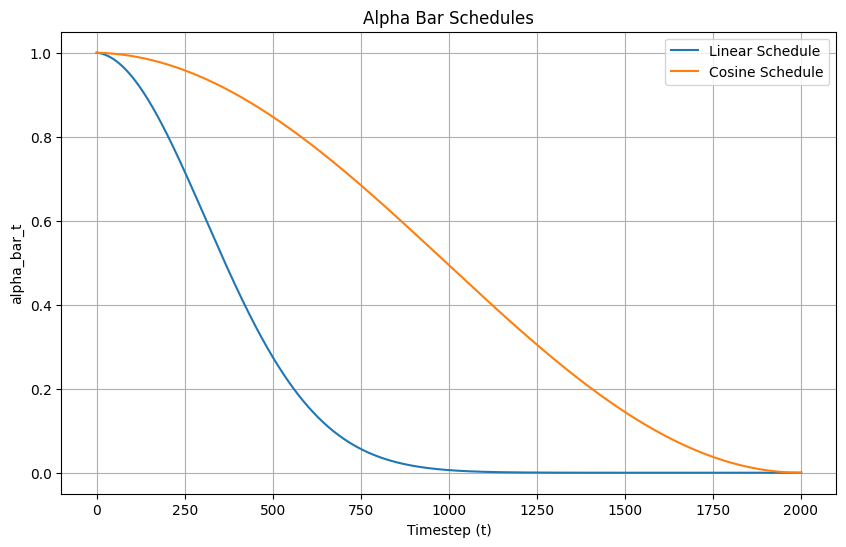

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(alpha_bars_linear.cpu().numpy(), label='Linear Schedule')
plt.plot(alpha_bars_cosine.cpu().numpy(), label='Cosine Schedule')
plt.title('Alpha Bar Schedules')
plt.xlabel('Timestep (t)')
plt.ylabel('alpha_bar_t')
plt.legend()
plt.grid(True)
plt.show()

Select which scheduler to use. To prevent broadcasting images, reshape all three lists to (T, 1, 1, 1). Put the tensors on the device, and if you used NumPy to create the tensors, convert from double to floats.

In [8]:
# betas_cosine already has β0=0 prepended (shape: T+1)
# So we use it directly without prepending again
b_schedule_full = betas_cosine

# Compute α = 1 − β
alphas_full = compute_alpha(b_schedule_full)

# Compute ᾱ = ∏ α
alpha_bars_full = compute_alpha_bar(alphas_full)

# Now extract (t = 1..T) as (t-1)-indexed arrays
betas = b_schedule_full[1:].reshape(-1, 1, 1, 1)
alphas = alphas_full[1:].reshape(-1, 1, 1, 1)
alpha_bars = alpha_bars_full[1:].reshape(-1, 1, 1, 1)

# Sometimes you explicitly need ᾱ0 = 1
alpha_bar_0 = alpha_bars_full[0].reshape(1, 1, 1, 1)

# Part 2: Implement the forward diffusion (training) process

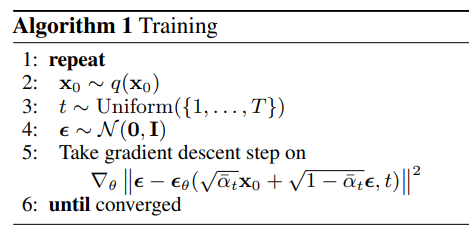

While you might be accustomed to pseudocode, deep learning pseudocode can sometimes be difficult to parse in the beginning and so we will explain all the steps here. The first thing to note is that **there is an implicit batch dimension included in the pseudocode**, so do not interpret this training loop as operating on a single image.

Line 2: Sample a batch of images $x_0$ from you dataset of images $q$. The subscript $0$ denotes the current timestep $t$, i.e. $x_{t=0} \equiv x_0$.

Line 3: Sample from the uniform distribution a batch of timesteps between 1 and $T$. The timesteps in the batch do not need to match.

Line 4: Sample noise from the normal distribution. In line 5 we see that the noise is going to be subtracted and multiplied element-wise to our batch of images. This means that the shape of the noise needs to match the shape of the batch of images, i.e. noise.shape = images.shape = (B, C, H, W).

Line 5: There is an implicit $x_t$ being created here where $x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$. Therefore, $x_t$ and $t$ are passed into our diffusion model $\epsilon_{\theta}$. The model's goal is to predict the noise $\epsilon$ that was added into the model. $\lVert \epsilon - \epsilon_{\theta}(x_t, t) \rVert^2$ is our loss and it means to take the mean squared error between $\epsilon$ and our model's prediction of $\epsilon$. The final two parts of line 5 are $\nabla_{\theta}$ and "take the gradient descent step" which translates into pytorch as call `loss.backward()` and `optimizer.step()` respectively.

Lines 1 and 6 mean to continually train your model until there is no improvement.

In [9]:
def training(model, optimizer, dataloader, n_minibatches=1500):
    model.train()

    losses = []
    data_iter = iter(dataloader)

    for i in range(n_minibatches):
        optimizer.zero_grad()

        try:
            x0, _ = next(data_iter)
        except StopIteration:
            # Restart the iterator when we run out of data
            data_iter = iter(dataloader)
            x0, _ = next(data_iter)

        x0 = x0.to(device)
        batch_size = x0.shape[0]

        # Sample timesteps t ~ Uniform({1,...,T})
        timesteps_batch = torch.randint(
            1, MAX_TIMESTEPS + 1,
            (batch_size,),
            device=device
        ).long()

        # Noise ε ~ N(0, I)
        noise = torch.randn_like(x0, device=device)

        # alpha_bars has shape (T, 1, 1, 1) and corresponds to t=1..T
        sqrt_alpha_bar_t = alpha_bars[timesteps_batch - 1].sqrt()
        sqrt_one_minus_alpha_bar_t = (1 - alpha_bars[timesteps_batch - 1]).sqrt()

        x_t = sqrt_alpha_bar_t * x0 + sqrt_one_minus_alpha_bar_t * noise

        # Model expects timesteps 0..T-1
        predicted_noise = model(x_t, timesteps_batch - 1)

        loss = F.mse_loss(noise, predicted_noise)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # <-- add this

        optimizer.step()

        losses.append(loss.item())

        if (i + 1) % 100 == 0:
            print(f"Minibatch {i+1}/{n_minibatches}, Loss: {loss.item():.4f}")

    return losses


# Part 3: Implement the backward diffusion (sampling) process

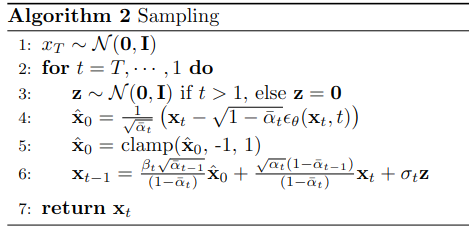

where $\bar{\alpha}_0 = 1$ and $\sigma_t = \sqrt{\beta_t}$.

**Note:** the only time $\alpha_t$ (without bar) is used instead of $\bar{\alpha}_t$ (with bar) is under the square root in the second term on line 6 (the numerator multiplied by $x_t$). If you mix up $\alpha$ and $\bar{\alpha}$, your sampling will not work!

In [10]:
@torch.no_grad()
def sampling(model, batch_size):
    model.eval()

    # x_T ~ N(0, I)
    img = torch.randn(
        batch_size,
        model.in_channels,
        image_size,
        image_size,
        device=device,
    )

    eps = 1e-5  # small constant for numerical stability

    for t in range(MAX_TIMESTEPS, 0, -1):
        t_idx = t - 1  # 0-based index

        # β_t, α_t, ᾱ_t shaped (1,1,1,1) – broadcast over img
        beta_t      = betas[t_idx]       # β_t
        alpha_t     = alphas[t_idx]      # α_t
        alpha_bar_t = alpha_bars[t_idx]  # \bar{α}_t

        # Clamp to avoid sqrt of negative and division by zero
        alpha_t_safe     = alpha_t.clamp(min=eps, max=1.0)
        one_minus_ab_safe = (1.0 - alpha_bar_t).clamp(min=eps, max=1.0)

        # model timestep in [0, T-1]
        timesteps_for_model = torch.full(
            (batch_size,),
            t_idx,
            device=device,
            dtype=torch.long,
        )

        eps_theta = model(img, timesteps_for_model)

        # μ_t(x_t, t) = 1/sqrt(α_t) * (x_t - β_t / sqrt(1-ᾱ_t) * ε_θ)
        one_over_sqrt_alpha_t    = 1.0 / alpha_t_safe.sqrt()
        beta_over_sqrt_one_mab   = beta_t / one_minus_ab_safe.sqrt()

        mean = one_over_sqrt_alpha_t * (img - beta_over_sqrt_one_mab * eps_theta)

        if t > 1:
            # σ_t^2 = β_t
            sigma_t = beta_t.clamp(min=eps).sqrt()
            z = torch.randn_like(img)
            img = mean + sigma_t * z
        else:
            img = mean

    # map [-1,1] -> [0,1]
    img = img.clamp(-1.0, 1.0)  # keep it in the range the model was trained on
    img = (img + 1.0) * 0.5

    return img


# Part 4: Train and generate images

In [11]:
preprocess_transform = Compose([
    Resize(image_size),
    ToTensor(),
    Lambda(lambda t: (t * 2) - 1),
])

In [12]:
model = UNetModel(
        in_channels=1,
        hidden_channels=64,
        out_channels=1,
        num_res_blocks=3,
        dropout=0.1,
        channel_mult=(1, 2, 2, 2),
    ).to(device)

batch_size = 64
dataset = torchvision.datasets.MNIST("data/", train=True, download=True, transform=preprocess_transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

optimizer = AdamW(model.parameters(), lr=lr)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 485kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 17.1MB/s]


In [13]:
train_losses = training(model, optimizer, dataloader, 5000)

Minibatch 100/5000, Loss: 0.4781
Minibatch 200/5000, Loss: 0.1438
Minibatch 300/5000, Loss: 0.0364
Minibatch 400/5000, Loss: 0.0426
Minibatch 500/5000, Loss: 0.0306
Minibatch 600/5000, Loss: 0.0331
Minibatch 700/5000, Loss: 0.0358
Minibatch 800/5000, Loss: 0.0332
Minibatch 900/5000, Loss: 0.0297
Minibatch 1000/5000, Loss: 0.0346
Minibatch 1100/5000, Loss: 0.0399
Minibatch 1200/5000, Loss: 0.0391
Minibatch 1300/5000, Loss: 0.0365
Minibatch 1400/5000, Loss: 0.0357
Minibatch 1500/5000, Loss: 0.0234
Minibatch 1600/5000, Loss: 0.0320
Minibatch 1700/5000, Loss: 0.0296
Minibatch 1800/5000, Loss: 0.0372
Minibatch 1900/5000, Loss: 0.0435
Minibatch 2000/5000, Loss: 0.0287
Minibatch 2100/5000, Loss: 0.0285
Minibatch 2200/5000, Loss: 0.0255
Minibatch 2300/5000, Loss: 0.0342
Minibatch 2400/5000, Loss: 0.0261
Minibatch 2500/5000, Loss: 0.0229
Minibatch 2600/5000, Loss: 0.0297
Minibatch 2700/5000, Loss: 0.0266
Minibatch 2800/5000, Loss: 0.0304
Minibatch 2900/5000, Loss: 0.0339
Minibatch 3000/5000, Lo

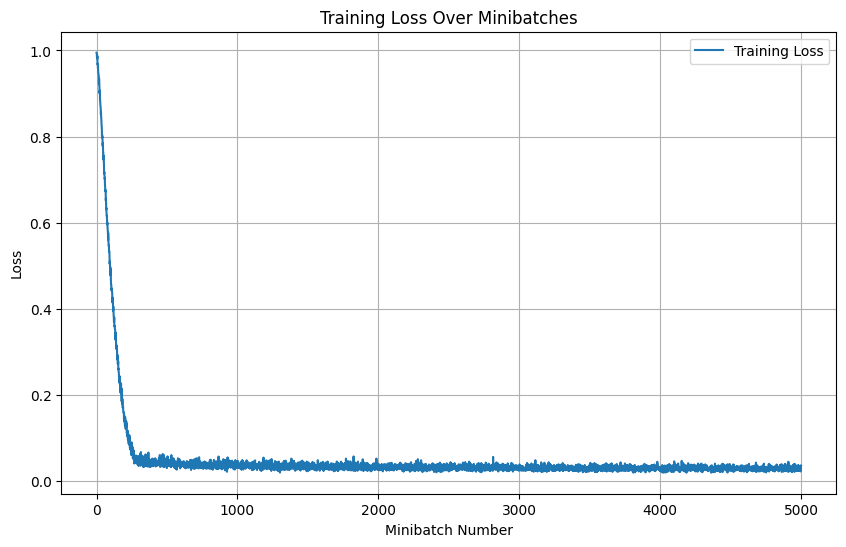

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.title('Training Loss Over Minibatches')
plt.xlabel('Minibatch Number')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

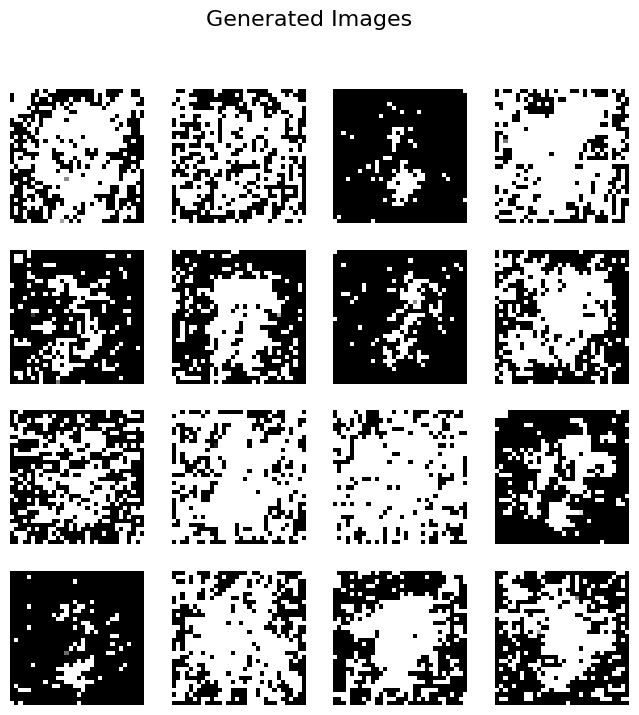

In [15]:
# Use sampling() to generate 16 images and plot them below
generated_images = sampling(model, batch_size=16)

plt.figure(figsize=(8, 8))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(generated_images[i].squeeze().cpu().numpy(), cmap='gray')
    plt.axis('off')
plt.suptitle('Generated Images', fontsize=16)
plt.show()

# Part 5: Questions

1. Where do we scale the values of our training data? What range do we scale the data to? Why do we scale the data in that range?

2. Why is the cosine scheduler better than the linear scheduler?

3. In the forward step, we perform a random number of denoising steps in one forward pass, but in the backward process, we have to perform T forward passes to generate images. Why is that?

4. What is our network learning to predict?

5. If we wanted to perform conditional generation; for example, if we wanted to provide our network with a digit and have it produce an image of that digit, what would we have to change?

1. We scale the data in the preprocessing step, before training begins. The images are mapped to the range [-1, 1]. This range matches the tanh-like output distribution the UNet expects, stabilizing training and making the noise prediction easier.
2. The cosine scheduler decreases the learning rate smoothly, with large steps early and tiny steps later. This helps avoid instability early in training and prevents the model from “overshooting” late in training. Overall, it leads to more stable convergence and better sample quality.
3. During training, the model only needs to learn how to denoise any single timestep, so we randomly choose one step per batch to reduce compute. But during sampling, we must actually reverse the entire diffusion process, which requires applying the denoising network for all T steps to remove noise gradually.
4. The network is trained to predict the noise ε that was added to the image at timestep t. By learning this noise, it can subtract it out during sampling. This effectively teaches the model how to reverse the diffusion process.
5. We would give the network an additional conditioning input, such as a one-hot digit label or an embedding. This conditioning information must be injected into the UNet (e.g., through concatenation, FiLM layers, cross-attention, or class embeddings). The training process would then teach the model to generate images consistent with that label.